# Why is there a one day periodicity in drifter-altimetry time gap diagnosis ?
## Necklace

In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt
from cstes import U

_______________
# Théorie
### For one trajectory :
- $cor(t) = C sin(\omega*t+\phi)$
- $ggd(t) = -C sin(\omega*t+\phi) + Noise$
We want to estimate :

$$ \langle cor(\Delta_t+\delta_{tc}k)\times ggd(\delta_{swot}k)\rangle_{k in ncycle} = -\frac{C^2}{2} cos(\omega |\Delta_t|)[1-\frac{sin((n+1)\omega \delta_{swot})}{(n+1)sin(\omega \delta_{swot})}cos(\omega \delta_{swot}n +2\phi)]$$

______
# Default parameters
- Pressure graident field noise but d
  stationnary
- $cor  = f u$ where $u_i(t) = A_i sin(2 \pi t/T + \phi_i)$
- $ggd = -cor + wnoise $
- We now look at the dependency on the time to swot time of $\langle cor*ggd \rangle$

In [11]:
N_traj = 20 #drifters
len_traj = 80 #days
dt_traj = 10/60/24 #10min in days

# For sinusoide velocities
amp = 0.5 #m/s
T = 2.345 #days
lat = 39
f = 2 * 2 * np.pi / 86164.1 * np.sin(lat * np.pi / 180)

#Added noise
ampn=0.5

#SWOT
dtCycle = 1 #days, time between each cycle
dt = 10 #days, max dt between traj-satellite 
nb_cycle = 40#days

def theoric_curve(ts, phi, nb_cycle, amp, f, T):
    n=nb_cycle-1
    np.random.seed(0)
    #phi = np.random.rand(N_traj)[i]*2*np.pi
    C = f*amp/U
    omega = 2*np.pi/T
    S = np.sin((n+1)*omega*dtCycle)/np.sin(omega*dtCycle)/(n+1)
    return -C**2/2 * np.cos(omega*ts)*(1-S*np.cos(n*omega*dtCycle+2*phi))

______

In [12]:
def build_necklace(traj, dt, tCycle):
    tneg =  np.sort(np.arange(0, -dt-dt_traj, -dt_traj))
    tpos = np.sort(np.arange(dt_traj, dt, dt_traj))
    ts = np.concatenate([tneg, tpos])
    cor = traj.cor.interp(traj_time= ts+tCycle).rename({'traj_time':'timetoswot'})
    ggd = traj.ggd.interp(traj_time= tCycle).rename({'traj_time':'tcycle'})

    ds= xr.merge([cor, ggd, (cor*ggd).rename('corggd').assign_attrs({'long_name':'cor(ts+tc)ggd(tc)'})])
    ds['timetoswot'] = ts
    return ds

    
def compute_for_all(N_traj = N_traj, len_traj = len_traj,dt_traj =dt_traj, amp=amp, T=T, lat=lat, f=f, ampn=ampn, dtCycle=dtCycle, dt=dt, nb_cycle=nb_cycle, noise=False ):
    # Initialize
    Tcycle = np.arange(0, nb_cycle, dtCycle)
    traj_time = np.arange(0, len_traj, dt_traj)
    drifter_id = np.arange(N_traj)
    dst = xr.DataArray(np.meshgrid(traj_time, drifter_id)[0], coords = {'drifter_id':drifter_id, 'traj_time':traj_time})
    np.random.seed(0)
    phi = xr.DataArray(np.random.rand(N_traj), coords = {'drifter_id':drifter_id}, name='phi')*2*np.pi
    np.random.seed(1)
    wnoise = xr.DataArray(f*ampn/U*(np.random.rand(N_traj, len(traj_time))-0.5), coords = {'drifter_id':drifter_id, 'traj_time':traj_time}, name='wnoise')
    dscor = (f*amp/U * np.sin(2*np.pi*dst/T + phi)).rename('cor')
    if noise : dsggd = (-dscor+wnoise).rename('ggd')
    else : dsggd = (-dscor).rename('ggd')
    ds = xr.merge([dscor, dsggd, wnoise, phi])


    
    #Necklace
    DD = []
    for d in range(N_traj) :
        traj = ds.sel(drifter_id=d).dropna('traj_time')
        D = []
        for tc in Tcycle :
            D.append(build_necklace(traj,dt, tc))
        DD.append(xr.concat(D, pd.Index(Tcycle, name = 'tcycle')))
    simple = xr.concat(DD, dim = 'drifter_id')
    pos = simple.where(simple.timetoswot >= 0, drop=True)
    neg = simple.where(simple.timetoswot <= 0, drop=True)
    neg['timetoswot'] = - neg['timetoswot']
    neg['tcycle'] = neg['tcycle']+ 0.5
    bended = xr.concat([pos, neg], dim = 'tcycle').sortby('tcycle')
    
    return ds, bended, simple

def plot_for_one_traj(ds, simple, bended, i) :
    dsp = simple.isel(drifter_id=i)
    concat = bended.isel(drifter_id=i)
    
    fig, axs = plt.subplots(2, 3, figsize=(15, 10))
    dsp.corggd.plot(ax = axs[0, 0])
    dsp.corggd.mean('tcycle').plot(ax = axs[1, 0])
    tt = theoric_curve(concat.timetoswot, ds.phi.isel(drifter_id=i), nb_cycle, amp, f, T)
    axs[1, 0].plot(concat.timetoswot, tt, ls=':')
    
    concat.corggd.plot(ax = axs[0, 1])
    concat.corggd.mean('tcycle').plot(ax = axs[1, 1])
    axs[1, 1].plot(concat.timetoswot, tt, ls=':')

    
    concat.corggd.sel(timetoswot = slice(0,1)).plot(ax = axs[0, 2])
    for i in range(0, dt) :
        axs[1, 0].axvline(i, ls=':')
        axs[1, 1].axvline(i, ls=':')
    
    for ax in axs[1,:]:
        ax.grid()

def plot_for_all(simple, bended) :
    fig, axs = plt.subplots(1,3, figsize=(15, 5))
    ax=axs[0]
    bended.corggd.mean('tcycle').mean('drifter_id').plot(ax=ax)
    for i in range(0, 10) :
        ax.axvline(i, ls=':')
    ax.grid()

    bended.corggd.count(dim='tcycle').mean('drifter_id').plot(ax=axs[1])
    

### T=2.345

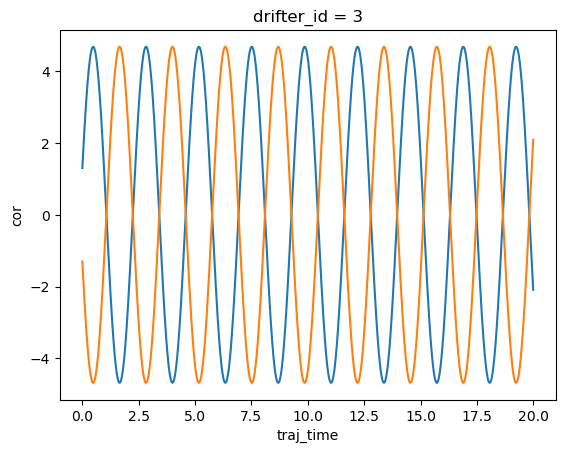

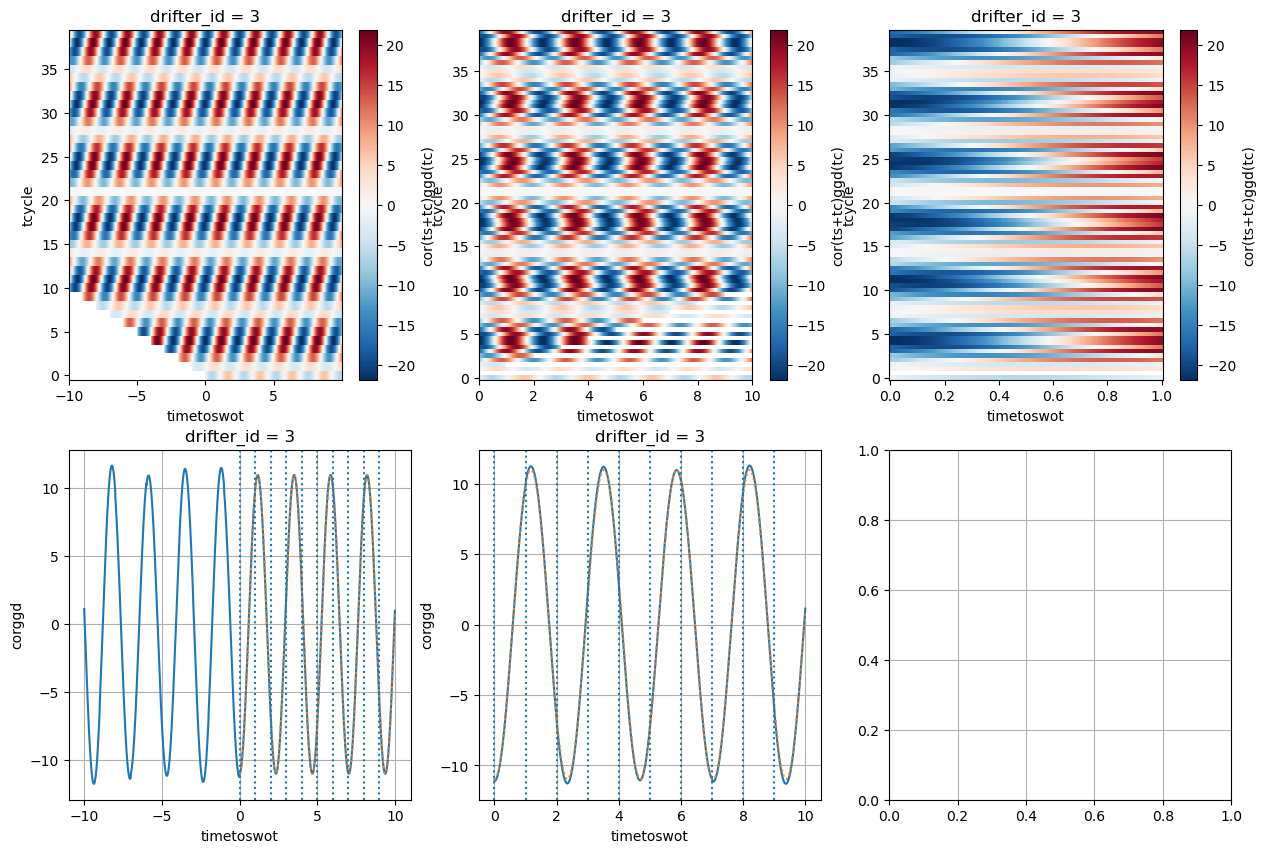

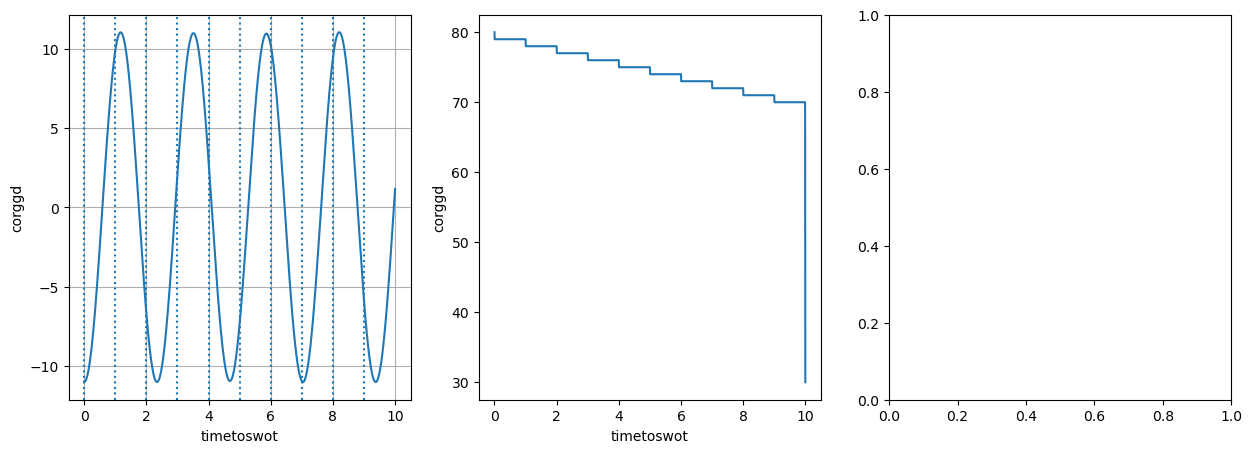

In [17]:
ds, bended, simple= compute_for_all()
i = 3
fig, ax = plt.subplots()
ds.ggd.isel(drifter_id=i).sel(traj_time = slice(0, 20)).plot(ax=ax)
ds.cor.isel(drifter_id=i).sel(traj_time = slice(0, 20)).plot(ax=ax)

plot_for_one_traj(ds, simple, bended, i)
plot_for_all(simple, bended)